#### Part A - Fundamentals

##### 1. What is Data Analysis?
Data analysis is the systematic process of inspecting, cleansing, transforming, and modeling raw data to discover useful information, draw conclusions, and support decision-making. In a business context, it bridges the gap between raw data collection and actionable strategies. Analysts use statistical tools and programming languages to uncover trends, diagnose problems, and predict future outcomes.



##### 2. Planning a Data Science Project
Planning a data science project typically follows a structured lifecycle. The core steps include:
* **Business Understanding:** Clearly define the project's objective, the problem to solve, and the success criteria.
* **Data Acquisition:** Gather raw data from relevant sources (e.g., SQL databases, APIs, CSV files).
* **Data Preparation & Cleaning:** Handle missing values, remove duplicates, fix inconsistencies, and format data types.
* **Exploratory Data Analysis (EDA):** Use statistical summaries and visualizations to understand data distributions and discover relationships.
* **Feature Engineering:** Transform existing data or create new variables to improve predictive power.
* **Modeling:** Select machine learning algorithms, train the models, and tune parameters.
* **Evaluation:** Assess model performance using metrics against a testing dataset.
* **Deployment & Monitoring:** Integrate the model into production and continuously monitor its performance.



##### 3. Machine Learning Problem Statement
**Problem Statement:** "The objective of this project is to build a binary classification model that predicts the probability of a customer ending their relationship with the company (churning) in the near future based on purchase behavior. By analyzing historical data, the model will identify 'at-risk' customers. This predictive insight will allow the business to proactively deploy targeted retention campaigns, thereby reducing overall churn rates."



##### 4. What are Tensors?
A tensor is a fundamental mathematical object and the core data structure used in modern machine learning. It is a container for numerical data, structured as an *n*-dimensional array. The dimensionality of a tensor is often referred to as its "rank" or "axis."

* **0D Tensor (Scalar):** A single number (zero dimensions).
* **1D Tensor (Vector):** An array of numbers (one dimension).
* **2D Tensor (Matrix):** A grid of numbers with rows and columns (two dimensions).
* **3D Tensor:** An array of matrices (three dimensions, commonly used for image data).

**NumPy Examples:**
```python
import numpy as np

# 0D Tensor (Scalar)
scalar = np.array(42)

# 1D Tensor (Vector)
vector = np.array([1, 2, 3, 4, 5])

# 2D Tensor (Matrix)
matrix = np.array([
    [28, 55000, 12],
    [45, 85000, 5]
])

# 3D Tensor
tensor_3d = np.array([
    [[255, 0, 0], [0, 255, 0]],
    [[0, 0, 255], [255, 255, 0]]
])

#### Part B - Data Acquisition

In [44]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# Load CSV

df_csv = pd.read_csv('customer_data1.csv')

df_json = pd.read_json('customer_data2.json')

conn = sqlite3.connect('customer_data.db')

df_sql = pd.read_sql_query("SELECT * FROM customers",conn)



In [42]:
# Join all the data

all_dfs = [df_csv,df_json,df_sql]
customers = pd.concat(all_dfs,ignore_index=True)

conn.close()

#### Part C - Data Understanding & Cleaning

In [27]:
customers.head()

,Customer_ID,Age,Gender,Income,Purchases,Churn
0,1001,56,Female,66940.86,28,1
1,1002,69,Male,44387.25,49,0
2,1003,46,Male,39713.24,30,0
3,1004,32,Female,51623.69,38,0
4,1005,60,Female,48026.47,4,1


In [28]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer_ID  300 non-null    int64  
 1   Age          300 non-null    int64  
 2   Gender       300 non-null    str    
 3   Income       300 non-null    float64
 4   Purchases    300 non-null    int64  
 5   Churn        300 non-null    int64  
dtypes: float64(1), int64(4), str(1)
memory usage: 14.2 KB


In [ ]:
# No missing values, duplicates and no need for any data cleaning since the data is perfect

In [37]:
customers[['Age','Income','Purchases']].describe()

,Age,Income,Purchases
count,300.000000,300.000000,300.000000
mean,43.320000,60251.809600,25.926667
std,15.326686,15894.964015,13.668114
min,18.000000,18230.470000,1.000000
25%,30.000000,49157.362500,15.000000
50%,43.500000,60825.565000,26.000000
75%,56.000000,71217.370000,37.000000
max,69.000000,104642.950000,49.000000


In [39]:
customers.shape

(300, 6)

#### Part D - Exploratory Data Analysis (EDA)

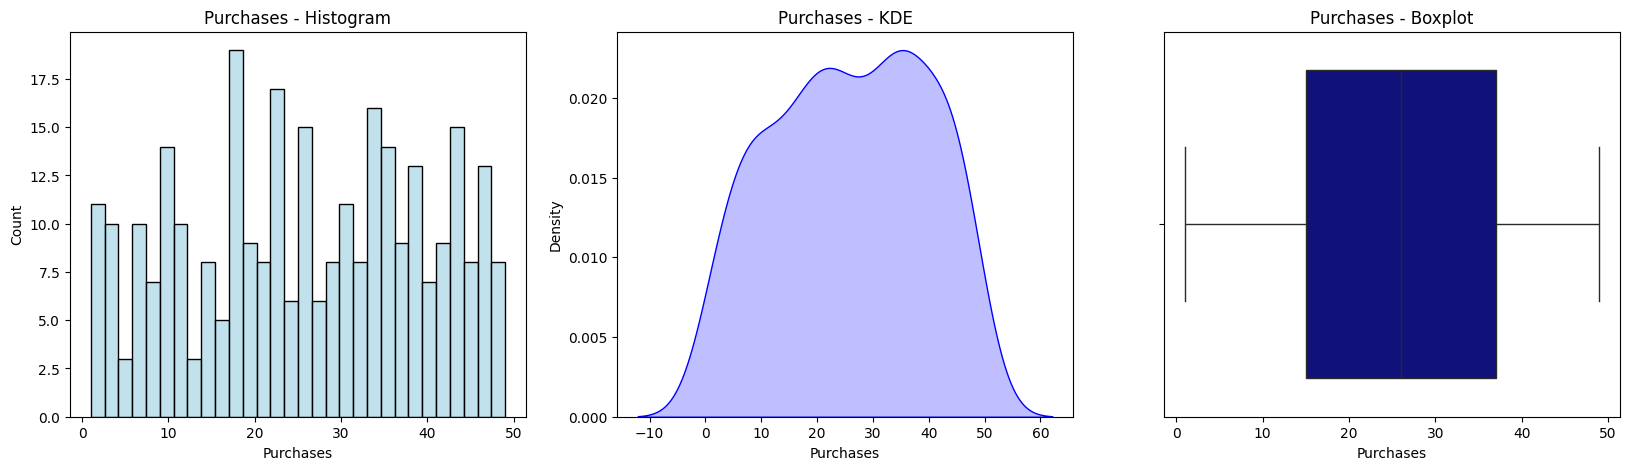

In [61]:
# Univariate Analysis

fig, axes = plt.subplots(1,3, figsize=(20,5))

sns.histplot(data=customers,x='Purchases',ax=axes[0], bins=30, color='lightblue')
axes[0].set_title('Purchases - Histogram')

sns.kdeplot(data=customers,x='Purchases',ax=axes[1], color='blue', fill=True)
axes[1].set_title('Purchases - KDE')

sns.boxplot(data=customers,x='Purchases',ax=axes[2], color='darkblue')
axes[2].set_title('Purchases - Boxplot')

plt.show()

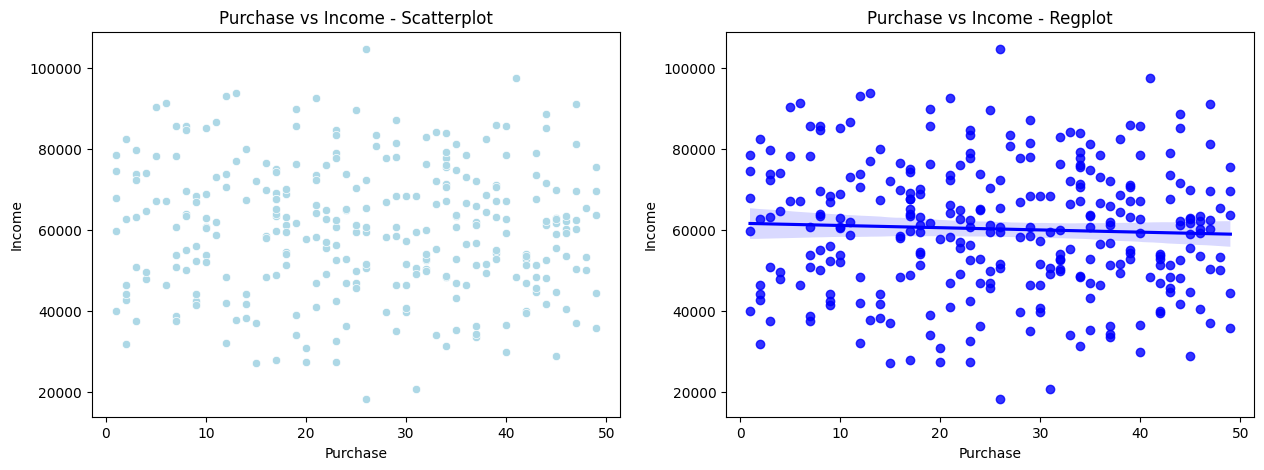

In [76]:
# Bivariate Analysis


fig, axes = plt.subplots(1,2, figsize=(15,5))

sns.scatterplot(data=customers,x='Purchases',y='Income',ax=axes[0], color='lightblue')
axes[0].set_xlabel('Purchase')
axes[0].set_ylabel('Income')
axes[0].set_title('Purchase vs Income - Scatterplot')


sns.regplot(data=customers,x='Purchases',y='Income',ax=axes[1], color='blue')
axes[1].set_xlabel('Purchase')
axes[1].set_ylabel('Income')
axes[1].set_title('Purchase vs Income - Regplot')

plt.show()


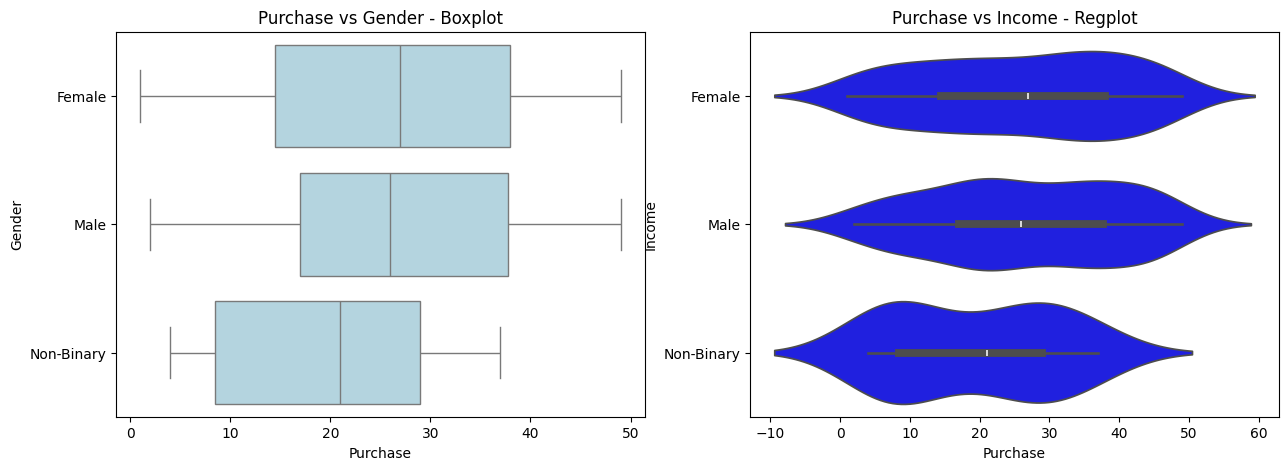

In [74]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

sns.boxplot(data=customers,x='Purchases',y='Gender',ax=axes[0], color='lightblue')
axes[0].set_xlabel('Purchase')
axes[0].set_ylabel('Gender')
axes[0].set_title('Purchase vs Gender - Boxplot')


sns.violinplot(data=customers,x='Purchases',y='Gender',ax=axes[1], color='blue')
axes[1].set_xlabel('Purchase')
axes[1].set_ylabel('Gender')
axes[1].set_title('Purchase vs Gender - Violinplot')

plt.show()

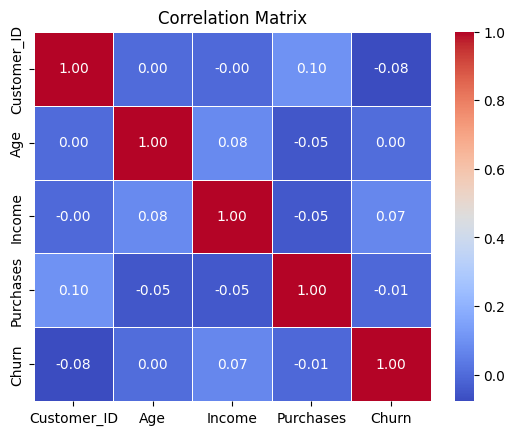

In [83]:
# Multivariate Analysis

corr = customers.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

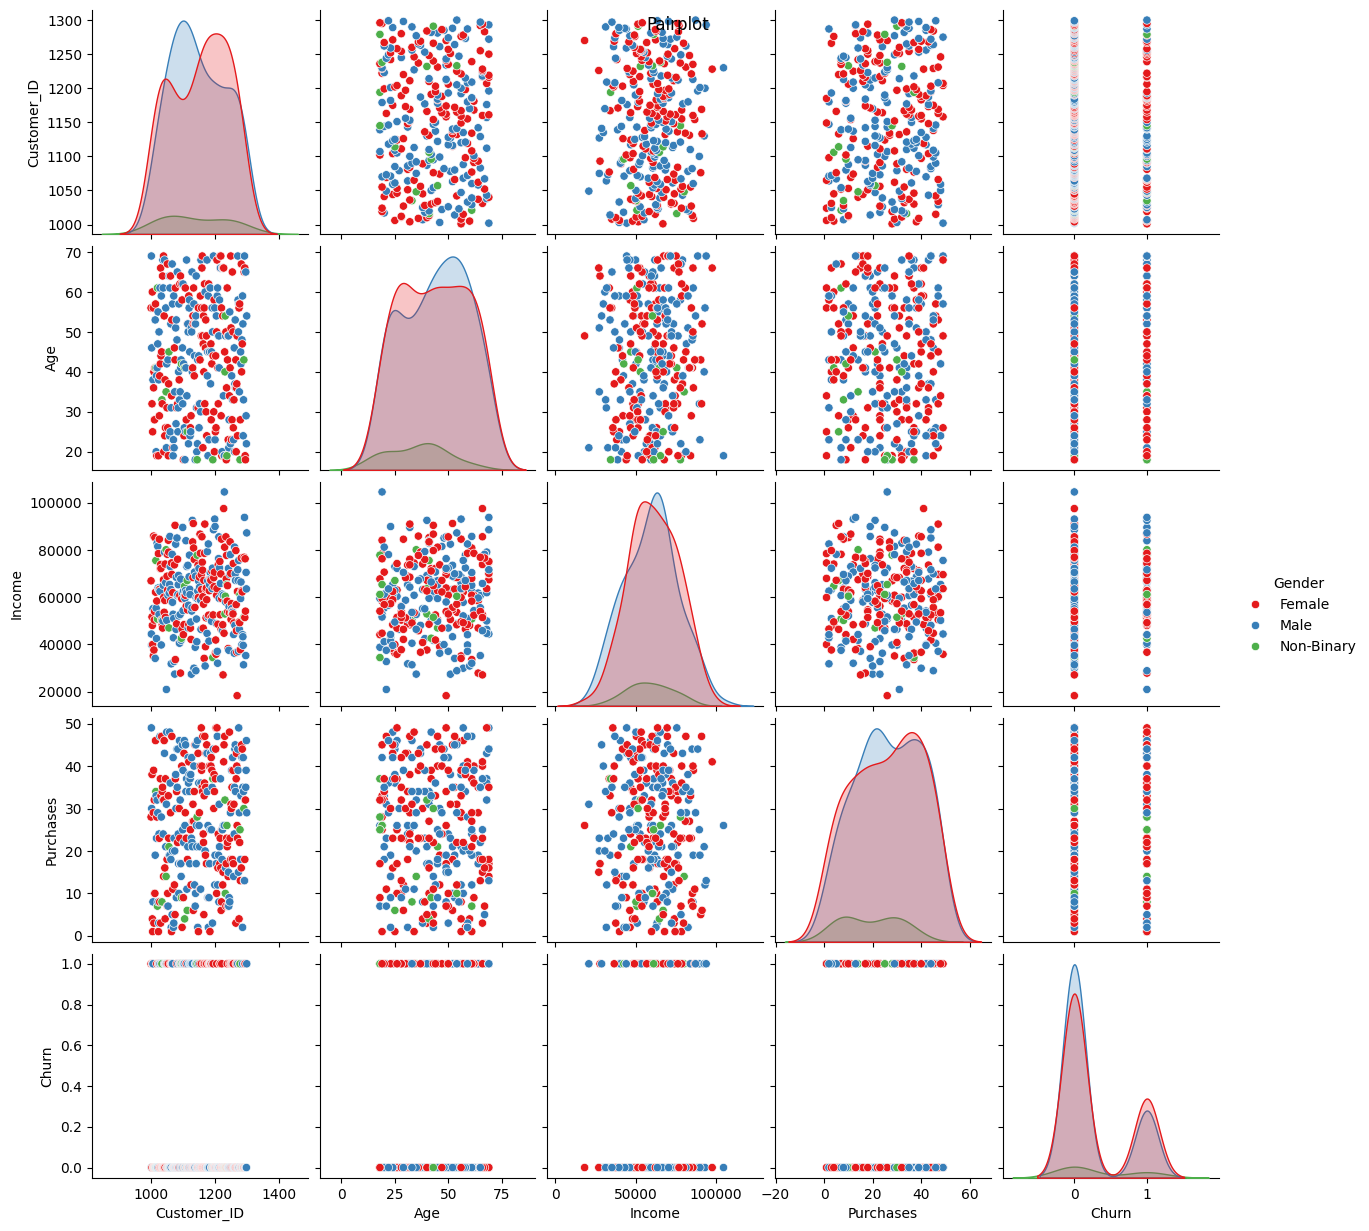

In [90]:
sns.pairplot(customers,hue='Gender',diag_kind='kde',palette='Set1')
plt.show()

#### Part E - Data Profiling

In [96]:
!pip install ydata_profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(customers, title ='Customer Data Profiling Report',explorative=True)

profile.to_file('customers_data_report.html')

profile.to_notebook_iframe()